In [54]:
from pathlib import Path
from matplotlib.path import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from ml_project.feature_engineering import feature_engineering

%matplotlib inline
sns.set_style('whitegrid')

In [55]:
from pathlib import Path
import pandas as pd

def get_data_path(filename):
    return Path().resolve().parent / 'input' / filename


df = pd.read_csv(get_data_path('train.csv'))



df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [56]:
# first look at the data

print(df.shape,end='\n\n')      
print(df.dtypes,end='\n\n')     

print(df.isnull().sum())


(891, 12)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [57]:

missing  = df.isnull().sum()
missin_pct = (missing/len(df)) * 100


missing_df  = pd.DataFrame({
    'Missing' : missing,
    'Percent' : missin_pct
}).sort_values('Percent',ascending=False)


print(missing_df[missing_df['Missing'] > 0])





          Missing    Percent
Cabin         687  77.104377
Age           177  19.865320
Embarked        2   0.224467


In [58]:
# we see that the Cabin,Age,Fare have missing values




# Cabin
df['Cabin'] = df['Cabin'].fillna('Unknown')

df['Has_Cabin'] = df['Cabin'].notnull().astype(int)

# Age
num_inputer  = SimpleImputer(strategy="median")

df['Age'] = num_inputer.fit_transform(df[['Age']])
df['Fare'] = num_inputer.fit_transform(df[['Fare']])












<Axes: >

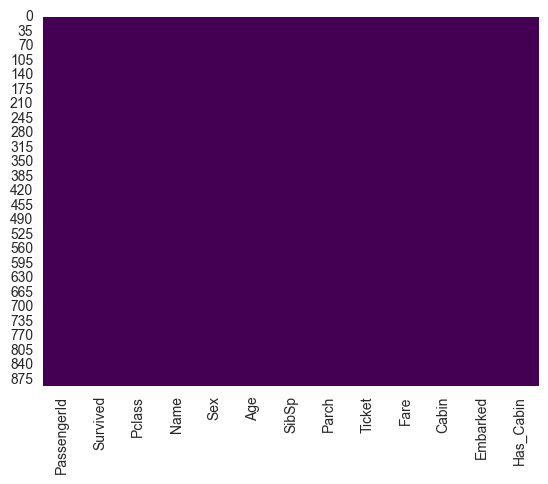

In [59]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis') # visualize missing values

# Univariate Analysis

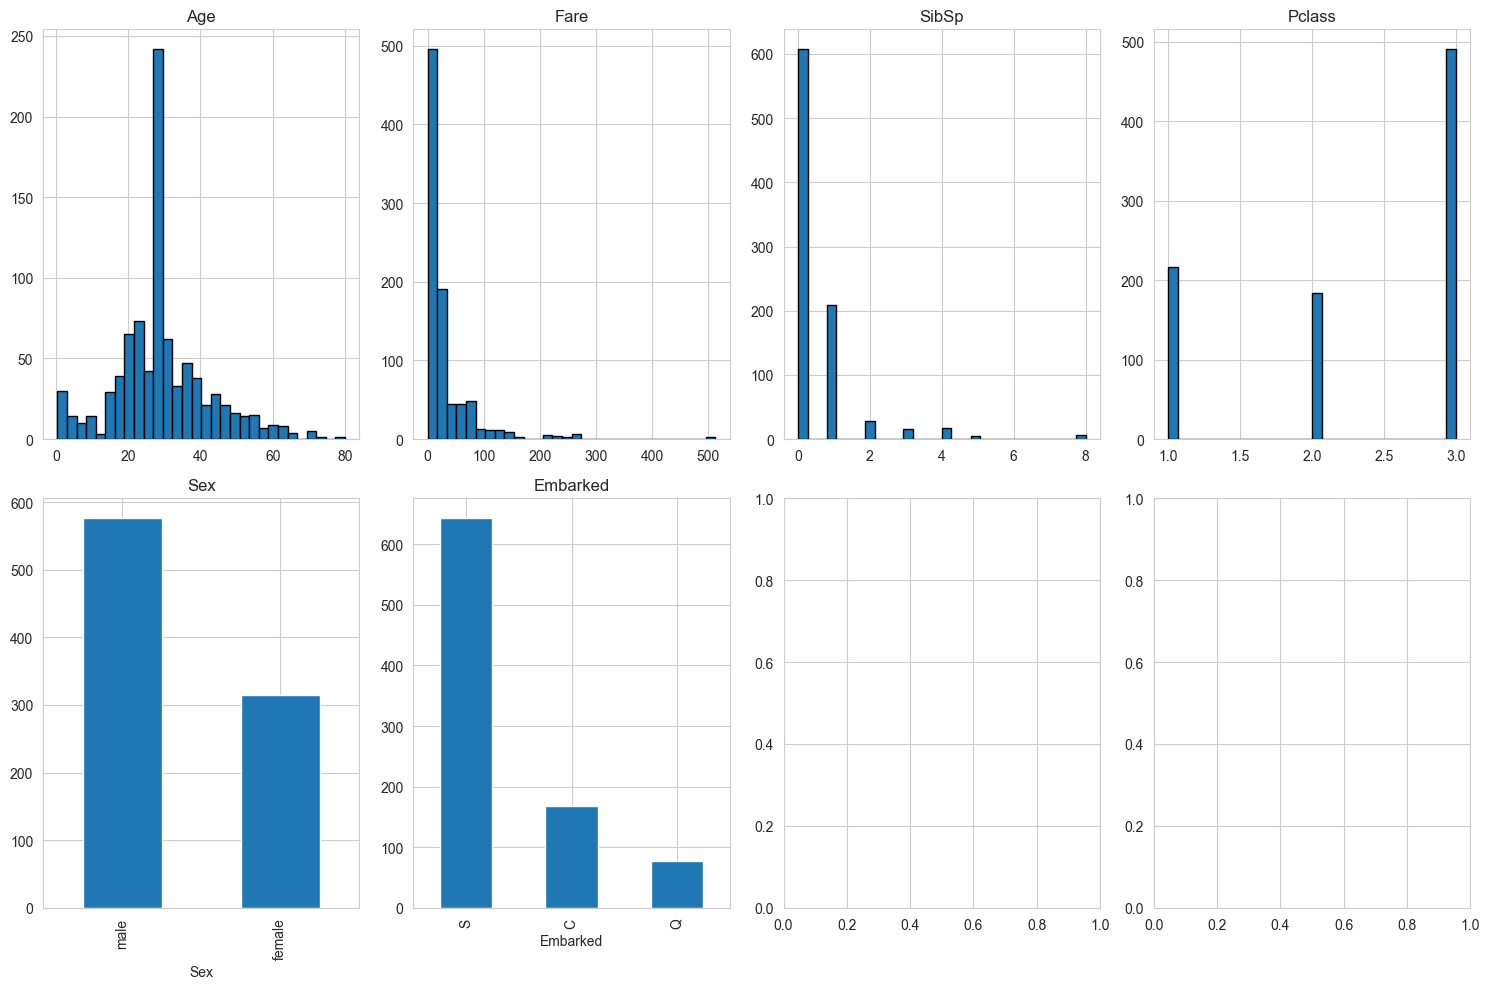

In [60]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))

for i, col in enumerate(['Age','Fare','SibSp','Pclass']):
    df[col].hist(ax=axes[0,i],bins=30,edgecolor='k')
    axes[0,i].set_title(col)


for i, col in enumerate(['Sex','Embarked']):
    df[col].value_counts().plot(kind="bar",ax=axes[1,i])
    axes[1,i].set_title(col)
    

plt.tight_layout()

In [61]:
df['Fare_log'] = np.log1p(df['Fare']) #TODO feature engineering of the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,Fare_log
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,1,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,1,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,1,2.202765


# Bivariate Analysis

C:\Users\denis\AppData\Local\Temp\ipykernel_9940\1132641913.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Survived', y='Age', palette='coolwarm')


<Axes: title={'center': 'Survival rate by Sex & Class'}>

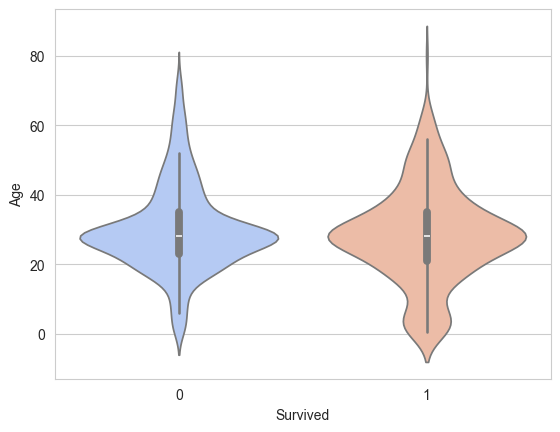

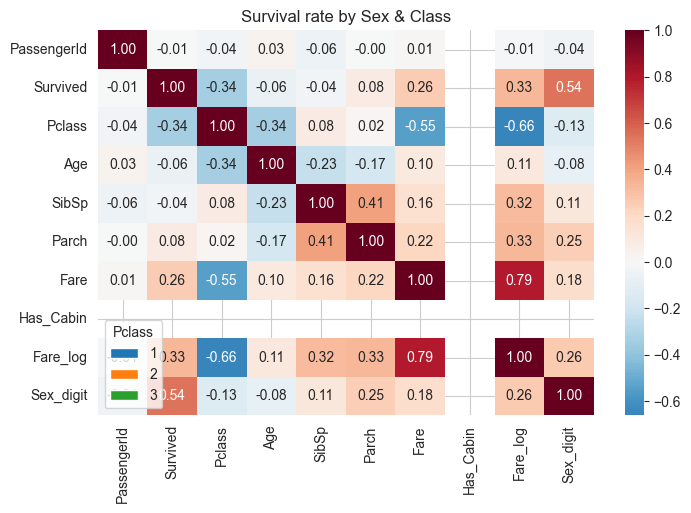

In [62]:
sns.violinplot(data=df, x='Survived', y='Age', palette='coolwarm')

df['Sex_digit'] = df['Sex'].map({'female': 1, 'male': 0})


survival_rate = df.groupby(['Sex', 'Pclass',])['Survived'].mean().unstack()
survival_rate.plot(kind='bar', figsize=(8, 5))
plt.title('Survival rate by Sex & Class')


corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')






# feature engineering

In [63]:

df = feature_engineering(df)

# Preprocessing Pipeline

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


numeric_features = ['Age', 'Fare', 'FamilySize']
categoric_features = ['Sex', 'Pclass', 'Title', 'Embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categoric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categoric_transformer, categoric_features),
    ]
)



In [65]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

# 80% train, 20% test, stratify = одинаковый % выживших
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



              precision    recall  f1-score   support

           0       0.83      0.89      0.86       110
           1       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



<Axes: >

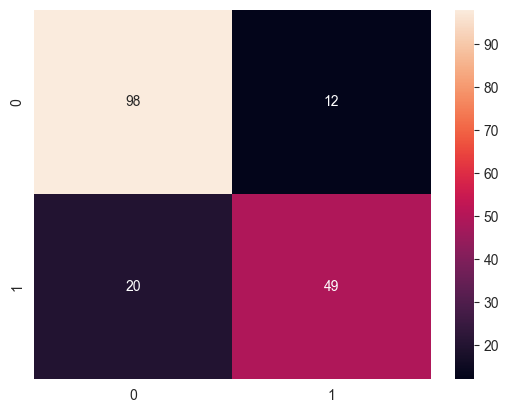

In [66]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression



model = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression())
    ]
)


y_pred = model.fit(X_train,y_train).predict(X_test)


print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')